# Bati Bank — Model Explainability

**Goal:** Understand WHY the model makes each credit decision using SHAP values.

**Why explainability matters:**
- Banks are legally required to explain credit decisions
- A customer rejected for BNPL can ask: 'why was I rejected?'
- SHAP gives a specific numerical answer per feature
- This satisfies Basel II regulatory requirements

**What SHAP value means:**
- Positive value → pushes prediction toward HIGH RISK
- Negative value → pushes prediction toward LOW RISK  
- Magnitude → how much it changed the final score

> Example: SHAP=+0.42 for velocity means this feature
> pushed the score UP by 0.42 — possibly changing Approve to Reject

## 1. Setup and Imports

In [1]:
# Cell 1 — imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

os.chdir('..')  # go up one level so Python finds src/

from src.model.explainer import Explainer

print('Imports successful')

Imports successful


## 2. Load Data and Model

In [2]:
# Cell 2 — load features and model
features = pd.read_csv('data/processed/features.csv')

# load model and feature names
model         = joblib.load('outputs/models/xgboost_model.pkl')
feature_names = joblib.load('outputs/models/feature_names.pkl')

# prepare X — same columns as training
drop_cols = ['CustomerId', 'Cluster', 'is_high_risk', 'Recency']
X = features.drop(columns=drop_cols)
y = features['is_high_risk']

print(f'Features shape : {X.shape}')
print(f'Feature names  : {feature_names}')

Features shape : (3742, 19)
Feature names  : ['Frequency', 'Monetary', 'avg_hour', 'avg_day_of_week', 'weekend_rate', 'transaction_month', 'std_amount', 'max_amount', 'min_amount', 'log_monetary', 'reversal_rate', 'unique_products', 'unique_providers', 'avg_daily_transactions', 'monetary_per_transaction', 'negative_amount_count', 'positive_amount_sum', 'velocity_last_30_days', 'recency_frequency_ratio']


## 3. Create SHAP Explainer

In [3]:
# Cell 3 — create SHAP TreeExplainer
# TreeExplainer is optimized for XGBoost — exact and fast
# KernelExplainer would work on any model but is very slow
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(f'SHAP values shape: {shap_values.shape}')
print(f'One row per customer, one column per feature')
print(f'Positive = increases risk, Negative = decreases risk')

SHAP values shape: (3742, 19)
One row per customer, one column per feature
Positive = increases risk, Negative = decreases risk


## 4. Global Explainability — All Customers

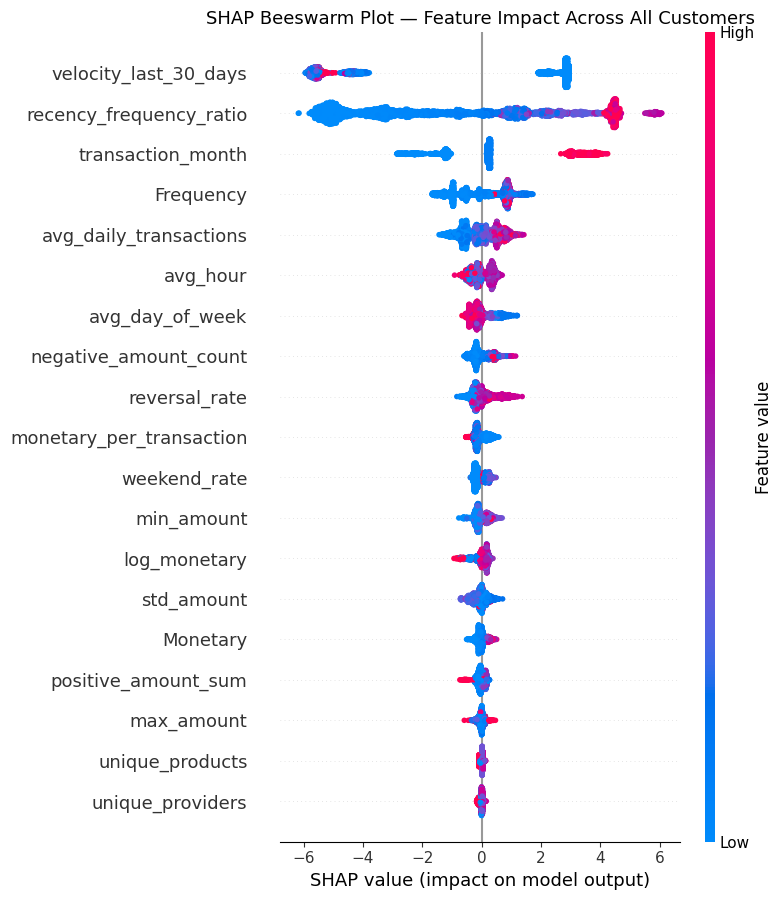

Saved: outputs/plots/shap_beeswarm.png


In [4]:
# Cell 4 — beeswarm plot
# shows distribution of SHAP values for every feature
# across all 3,742 customers
#
# How to read it:
#   x axis = SHAP value (left=decreases risk, right=increases risk)
#   each dot = one customer
#   color    = feature value (red=high, blue=low)
#   features sorted by total importance (top = most important)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact Across All Customers',
          fontsize=13)
plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/shap_beeswarm.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/plots/shap_beeswarm.png')

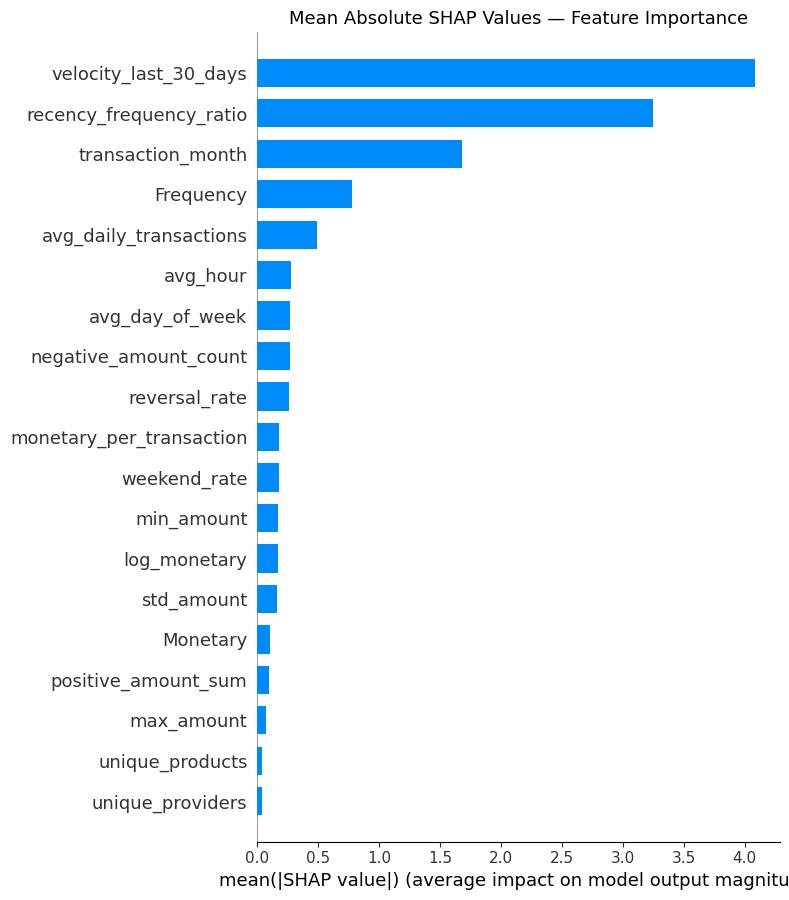

Saved: outputs/plots/shap_importance_bar.png


In [5]:
# Cell 5 — mean absolute SHAP values (bar chart)
# simpler than beeswarm — shows average importance per feature
# use this in README — easier for non-technical readers

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Mean Absolute SHAP Values — Feature Importance',
          fontsize=13)
plt.tight_layout()
plt.savefig('outputs/plots/shap_importance_bar.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/plots/shap_importance_bar.png')

### Global SHAP observations

Fill in after running:

1. **Most important feature:** ___
   - High value (red) → ___ risk
   - Low value (blue) → ___ risk
   - Business meaning: ___

2. **Second most important:** ___
   - Business meaning: ___

3. **Third most important:** ___
   - Business meaning: ___

4. **Features that decrease risk (negative SHAP):** ___

## 5. Local Explainability — Single Customer

In [6]:
# Cell 6 — explain one HIGH RISK customer
# pick the customer with highest predicted risk score
y_proba    = model.predict_proba(X)[:, 1]
high_risk_idx = y_proba.argmax()

print(f'Highest risk customer index : {high_risk_idx}')
print(f'Risk score                  : {y_proba[high_risk_idx]:.4f}')
print(f'Actual label                : {y.iloc[high_risk_idx]}')
print(f'\nCustomer features:')
print(X.iloc[high_risk_idx])

Highest risk customer index : 1538
Risk score                  : 1.0000
Actual label                : 1

Customer features:
Frequency                      11.000000
Monetary                    15780.000000
avg_hour                       13.910000
avg_day_of_week                 1.910000
weekend_rate                    0.181800
transaction_month              11.000000
std_amount                   2353.229116
max_amount                   8000.000000
min_amount                   -100.000000
log_monetary                    9.666562
reversal_rate                  45.450000
unique_products                 3.000000
unique_providers                3.000000
avg_daily_transactions          3.670000
monetary_per_transaction     1434.550000
negative_amount_count           5.000000
positive_amount_sum         16000.000000
velocity_last_30_days           0.000000
recency_frequency_ratio         7.373600
Name: 1538, dtype: float64


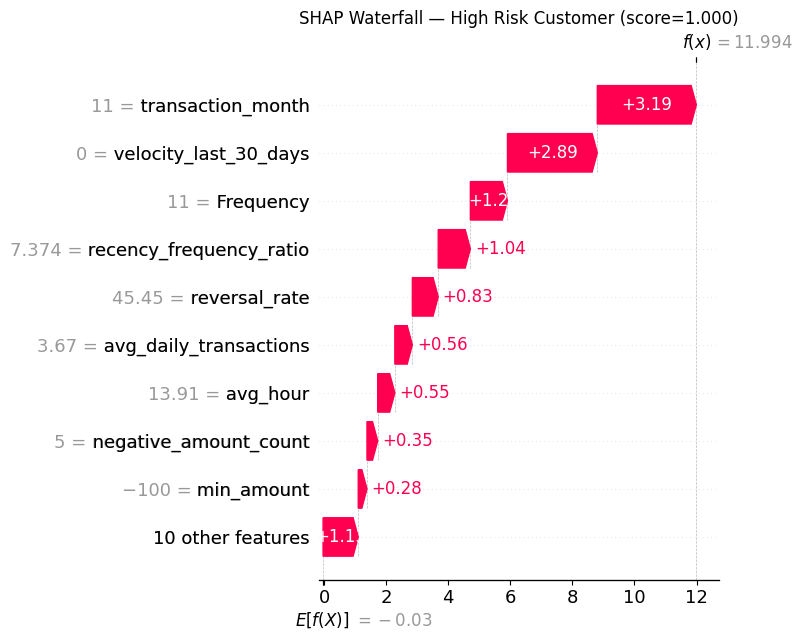

Saved: outputs/plots/shap_waterfall_high_risk.png


In [7]:
# Cell 7 — waterfall plot for high risk customer
# most detailed SHAP chart — shows exactly how each feature
# pushed the score from the base value to the final score
#
# How to read it:
#   E[f(x)] = base value (average prediction across all customers)
#   f(x)    = final prediction for this customer
#   red bars = features that increased risk
#   blue bars = features that decreased risk

shap_explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X.iloc[high_risk_idx].values,
    feature_names = feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — High Risk Customer (score={y_proba[high_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.savefig('outputs/plots/shap_waterfall_high_risk.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/plots/shap_waterfall_high_risk.png')

In [8]:
# Cell 8 — explain one LOW RISK customer
low_risk_idx = y_proba.argmin()

print(f'Lowest risk customer index : {low_risk_idx}')
print(f'Risk score                 : {y_proba[low_risk_idx]:.4f}')
print(f'Actual label               : {y.iloc[low_risk_idx]}')

Lowest risk customer index : 1354
Risk score                 : 0.0000
Actual label               : 0


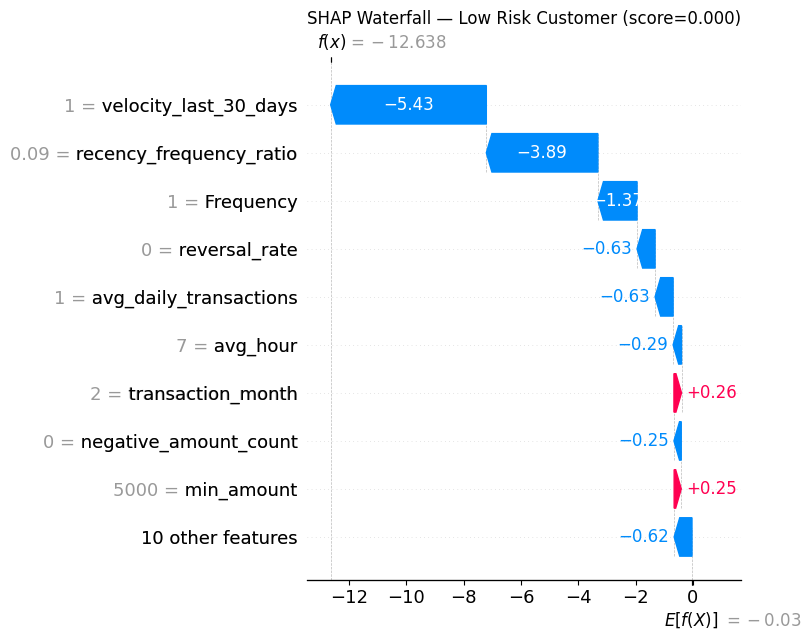

Saved: outputs/plots/shap_waterfall_low_risk.png


In [9]:
# Cell 9 — waterfall plot for low risk customer
shap_explanation_low = shap.Explanation(
    values        = shap_values[low_risk_idx],
    base_values   = explainer.expected_value,
    data          = X.iloc[low_risk_idx].values,
    feature_names = feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation_low, show=False)
plt.title(f'SHAP Waterfall — Low Risk Customer (score={y_proba[low_risk_idx]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.savefig('outputs/plots/shap_waterfall_low_risk.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/plots/shap_waterfall_low_risk.png')

### Local SHAP observations

Fill in after running:

**High risk customer:**
- Risk score: ___
- Top feature pushing toward risk: ___ (SHAP=___)
- In plain English: ___
- What would a bank analyst do with this information?

**Low risk customer:**
- Risk score: ___
- Top feature pushing toward safety: ___ (SHAP=___)
- In plain English: ___

## 6. Use Explainer Class

In [10]:
# Cell 10 — test the Explainer class
# this is what FastAPI calls on every prediction request
explainer_class = Explainer()

# take one customer as a dict
customer = X.iloc[high_risk_idx].to_dict()

# get explanation
explanation = explainer_class.explain(customer)

print('SHAP explanation from Explainer class:')
print(f'{"Feature":<35} {"Impact":>10} {"Direction"}')
print('-' * 65)
for item in explanation:
    print(f'{item["feature"]:<35} {item["impact"]:>10.4f}  {item["direction"]}')

SHAP explanation from Explainer class:
Feature                                 Impact Direction
-----------------------------------------------------------------
transaction_month                       3.1896  increases risk
velocity_last_30_days                   2.8941  increases risk
Frequency                               1.1955  increases risk
recency_frequency_ratio                 1.0358  increases risk


## 7. Save SHAP Values

In [11]:
# Cell 11 — save SHAP values for dashboard use
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)
shap_df.to_csv('data/processed/shap_values.csv', index=False)
print(f'Saved: data/processed/shap_values.csv')
print(f'Shape: {shap_df.shape}')

Saved: data/processed/shap_values.csv
Shape: (3742, 19)


## 8. Explainability Summary

| Chart | What it shows | Where used |
|---|---|---|
| Beeswarm | Distribution of SHAP values across all customers | README, notebook |
| Bar chart | Mean absolute importance per feature | README, dashboard |
| Waterfall | How each feature pushed ONE customer's score | Dashboard per prediction |

**Key findings:** _(fill in after running)_

1. Most important feature: ___
2. Biggest risk driver: ___
3. Biggest safety signal: ___

**Regulatory compliance:**
- Every prediction has a SHAP explanation ✓
- Bank analyst can see exactly why each customer was approved/rejected ✓
- Satisfies Basel II explainability requirement ✓

**Next step:** `src/api/` — FastAPI endpoints